# ARTI 402 — Deep Learning
## Lab 5 — Optimizers: SGD, Mini-batches, Momentum, RMSProp and Adam

**Week 5 · Optimization Algorithms**
Gradient descent variants: stochastic gradient descent (SGD), mini-batch SGD; adaptive learning
rate methods: Adam, RMSProp.

| | |
|---|---|
| **Marks** | **1 mark** (graded) |
| **Estimated time** | 100–120 minutes |
| **Prerequisites** | Lab 2 (gradients, `numerical_gradient`, the chain rule) |
| **Reference** | Kinsley & Kukieła, *Neural Networks from Scratch in Python*, **Ch. 9–10** |



---

### How to work through the notebook

* Sections are labelled **Idea** (read and run), **Exercise** (you write code) and **Checkpoint** (a short answer).
* Every exercise cell is marked `# TODO`. Do not delete the cells above it — later cells depend on them.
* Run cells **in order**, top to bottom. If something breaks, restart the kernel and run all.
* The graded **Assessment** is at the very end.

---

### The black box opens today

Since Lab 2 you have trained networks with `numerical_gradient` — nudge every weight, measure the
loss, repeat. It is correct and painfully slow, and Labs 3 and 4 hid it inside `train_head`.

Today you replace it with **real backpropagation**, check that it gives the same answers, and then
spend the rest of the lab on the question that decides whether training works at all:

> *Given the gradient, how exactly should we step?*

We work in four stages: **see it → open it → build it → race it.**

### By the end of this lab you should be able to

1. Run a full forward and backward pass, and verify backprop against numerical gradients.
2. Implement SGD, and explain the difference between an **epoch** and an **iteration**.
3. Train with **mini-batches**, and explain the trade-off in batch size.
4. Implement **momentum**, **RMSProp** and **Adam**, and say what problem each one fixes.
5. Compare optimizers fairly, and recognise when a learning rate is too small or too large.


## Setup

### Files you need

Put this file in the **same folder** as the notebook:

| File | What it is |
|---|---|
| `arti402_figures.py` | draws the diagrams (updated version — it replaces Lab 4's) |

### The code

`spiral_data` is the dataset from *Neural Networks from Scratch*. `numerical_gradient` is your
Lab 2 function — it comes back one last time, as the thing we check backprop against.


In [6]:
import sys
import time
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)


def spiral_data(samples, classes, seed=0):
    """The NNFS spiral dataset: `classes` interleaved spiral arms."""
    rng = np.random.RandomState(seed)
    X = np.zeros((samples * classes, 2))
    y = np.zeros(samples * classes, dtype="uint8")
    for class_number in range(classes):
        ix = range(samples * class_number, samples * (class_number + 1))
        r = np.linspace(0.0, 1, samples)
        t = np.linspace(class_number * 4, (class_number + 1) * 4, samples) \
            + rng.randn(samples) * 0.2
        X[ix] = np.c_[r * np.sin(t * 2.5), r * np.cos(t * 2.5)]
        y[ix] = class_number
    return X, y


def numerical_gradient(param, loss_fn, h=1e-6):
    """Lab 2's method: nudge every value, measure the loss. Correct but slow."""
    grad = np.zeros_like(param)
    it = np.nditer(param, flags=["multi_index"])
    while not it.finished:
        idx = it.multi_index
        original = param[idx]
        param[idx] = original + h; loss_plus = loss_fn()
        param[idx] = original - h; loss_minus = loss_fn()
        param[idx] = original
        grad[idx] = (loss_plus - loss_minus) / (2 * h)
        it.iternext()
    return grad


X_train, y_train = spiral_data(samples=100, classes=3, seed=0)
X_test,  y_test  = spiral_data(samples=100, classes=3, seed=1)

print("Python :", sys.version.split()[0])
print("NumPy  :", np.__version__)
print("train:", X_train.shape, " test:", X_test.shape)
print("\nSetup OK")

Python : 3.13.5
NumPy  : 2.1.3
train: (300, 2)  test: (300, 2)

Setup OK


In [7]:
# Diagrams live in arti402_figures.py, in the same folder as this notebook.
from arti402_figures import (draw_spiral_data, draw_optimizer_family,
                             draw_valley_paths, draw_loss_curves,
                             draw_decision_boundaries)

print("figure helpers loaded")

figure helpers loaded


# Stage 1 · See it

## Idea 1 — Same network, same data, different results

### Do this now (10 minutes)

Open the **[TensorFlow Playground](https://playground.tensorflow.org)**. It trains a real neural
network in your browser.

1. Under **DATA** on the left, pick the **spiral** (bottom-right of the four small pictures).
2. Press **play** ▶ and let it run for a few hundred epochs. Watch the background colours bend to
   follow the spiral, and the **test loss** at the top right fall.
3. Press **reset** ⟲. Set **Learning rate** (top bar) to **3** and press play. Watch.
4. Reset again. Set **Learning rate** to **0.0001** and press play. Watch.
5. Reset. Set it back to **0.03**, and try the **Batch size** slider (bottom left) at **1**, then **30**.

### What you should have seen

Nothing about the network changed between those runs — same layers, same neurons, same data.
Only **how it steps downhill** changed, and that alone decided between learning the spiral,
learning nothing, and flailing wildly.

That "how it steps" is the **optimizer**, and it is today's topic.

Here is our own copy of the spiral, from the textbook. A straight line cannot separate these
classes — the network has to learn curved boundaries, which makes it a good test of optimizers.


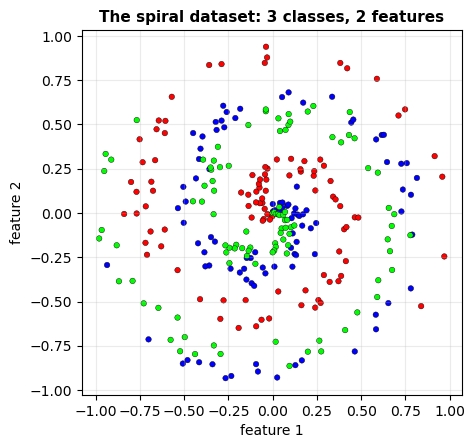

In [8]:
fig = draw_spiral_data(X_train, y_train)
plt.show()

# Stage 2 · Open the black box

## Idea 2 — Backpropagation for a whole network

In Lab 2, Exercise 8, you pushed a gradient backwards through **one neuron** with the chain rule.
A whole network is the same thing, repeated layer by layer, in **reverse order**.

Each layer gets a `backward(dvalues)` method, where `dvalues` is the gradient arriving **from the
layer above**. Each backward call does two jobs:

1. works out the gradient for **its own** parameters — `dweights` and `dbiases`, which the
   optimizer will use,
2. works out `dinputs`, the gradient to **pass down** to the layer below.

The three classes below are from NNFS Chapter 9. **Read them; you do not need to derive them.**
The comments say what each line means.


In [9]:
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

    def forward(self, inputs):
        self.inputs = inputs                          # remembered for the backward pass
        self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues)          # for the optimizer
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)   # for the optimizer
        self.dinputs = np.dot(dvalues, self.weights.T)          # passed to the layer below


class Activation_ReLU:
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.maximum(0, inputs)

    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
        self.dinputs[self.inputs <= 0] = 0       # the gate from Lab 2: shut where input <= 0


class Activation_Softmax_Loss_CategoricalCrossentropy:
    """Softmax and cross-entropy together - their combined gradient is very simple."""

    def forward(self, inputs, y_true):
        exp = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        self.output = exp / np.sum(exp, axis=1, keepdims=True)
        clipped = np.clip(self.output, 1e-7, 1 - 1e-7)
        return np.mean(-np.log(clipped[range(len(clipped)), y_true]))

    def backward(self, dvalues, y_true):
        n = len(dvalues)
        self.dinputs = dvalues.copy()
        self.dinputs[range(n), y_true] -= 1      # predicted probability minus the truth
        self.dinputs = self.dinputs / n          # averaged over the batch


print("backprop classes ready")

backprop classes ready


That last class hides a small miracle. Softmax and cross-entropy each have messy derivatives,
but combined, the gradient is just **predicted probability minus the correct answer**. If the
network says 0.7 for the right class, the gradient there is 0.7 − 1 = −0.3: *push that one up.*
NNFS Chapter 9 derives it if you are curious.


### Exercise 1 — wire up the network, then check it against Lab 2

Complete `forward` and `backward`. The forward pass runs dense1 → ReLU → dense2 → softmax+loss.
The backward pass runs **the same four steps in reverse**, each one fed the `dinputs` of the step
before it.


In [10]:
class SpiralNet:
    """dense(2 -> 64) -> ReLU -> dense(64 -> 3) -> softmax + loss.  NNFS Ch. 10's network."""

    def __init__(self, seed=0):
        np.random.seed(seed)
        self.dense1 = Layer_Dense(2, 64)
        self.activation1 = Activation_ReLU()
        self.dense2 = Layer_Dense(64, 3)
        self.loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()

    def forward(self, X, y):
        """Returns the loss."""
        self.dense1.forward(X)
        self.activation1.forward(self.dense1.output)
        self.dense2.forward(self.activation1.output)
        loss = self.loss_activation.forward(self.dense2.output, y)
        return loss

    def backward(self, y):
        # the loss layer starts the chain, from its own output
        self.loss_activation.backward(self.loss_activation.output, y)
        self.dense2.backward(self.loss_activation.dinputs)
        self.activation1.backward(self.dense2.dinputs)
        self.dense1.backward(self.activation1.dinputs)

    def accuracy(self, X, y):
        self.forward(X, y)
        return np.mean(np.argmax(self.loss_activation.output, axis=1) == y)


# --- self-check: backprop against Lab 2's numerical gradient ---
net = SpiralNet(seed=0)
loss = net.forward(X_train, y_train)
net.backward(y_train)

loss_fn = lambda: net.forward(X_train, y_train)
num_dw1 = numerical_gradient(net.dense1.weights, loss_fn)
num_db2 = numerical_gradient(net.dense2.biases, loss_fn)

print(f"starting loss: {loss:.4f}   (ln 3 = {np.log(3):.4f})")
print(f"largest difference, dense1 weights: {np.max(np.abs(net.dense1.dweights - num_dw1)):.2e}")
print(f"largest difference, dense2 biases : {np.max(np.abs(net.dense2.dbiases - num_db2)):.2e}")

assert abs(loss - np.log(3)) < 0.01, "an untrained 3-class network should start near ln(3)"
assert np.allclose(net.dense1.dweights, num_dw1, atol=1e-7), \
    "backprop disagrees with the numerical gradient - check the ORDER of the backward calls"
assert np.allclose(net.dense2.dbiases, num_db2, atol=1e-7)
print("\nExercise 1 passed - backprop agrees with Lab 2's method.")

starting loss: 1.0986   (ln 3 = 1.0986)
largest difference, dense1 weights: 1.87e-10
largest difference, dense2 biases : 6.30e-11

Exercise 1 passed - backprop agrees with Lab 2's method.


Same answers. Now the reason it matters — speed. The cell times one full gradient computation
both ways, for all 387 parameters of this network.


In [11]:
net = SpiralNet(seed=0)
params = [net.dense1.weights, net.dense1.biases, net.dense2.weights, net.dense2.biases]
n_params = sum(p.size for p in params)

t0 = time.time()
for _ in range(20):
    net.forward(X_train, y_train)
    net.backward(y_train)
t_backprop = (time.time() - t0) / 20

t0 = time.time()
for p in params:
    numerical_gradient(p, lambda: net.forward(X_train, y_train))
t_numerical = time.time() - t0

print(f"parameters                     : {n_params}")
print(f"numerical gradient (Lab 2 way) : {t_numerical * 1000:8.1f} ms per step")
print(f"backpropagation                : {t_backprop * 1000:8.2f} ms per step")
print(f"speed-up                       : about {t_numerical / t_backprop:,.0f}x")

parameters                     : 387
numerical gradient (Lab 2 way) :    265.4 ms per step
backpropagation                :     0.87 ms per step
speed-up                       : about 304x


And this network is tiny. The speed-up grows with every parameter you add, because numerical
gradients need two extra forward passes **per parameter** while backprop needs one backward pass
**in total**. That was Lab 2's Q4(3), and now you have measured it.

From here on, gradients are cheap. The interesting question becomes what to do with them.


# Stage 3 · Build the optimizers

## Idea 3 — The optimizer's job, and how it plugs in

After a backward pass, every layer holds `dweights` and `dbiases`. The optimizer's job is to use
them to update `weights` and `biases`. NNFS gives every optimizer the same three methods:

| method | when it runs | what it does |
|---|---|---|
| `pre_update_params()` | once, before updating | adjust the learning rate (**decay**) |
| `update_params(layer)` | once per layer | **the actual step** — this is what you write |
| `post_update_params()` | once, after updating | count the step |

The base class below handles the bookkeeping. Every optimizer you write inherits from it and only
has to fill in `update_params`.

### Learning-rate decay

Early in training you want big steps; near the end, small careful ones. **Decay** shrinks the
learning rate as training goes on:

```
current_learning_rate = learning_rate / (1 + decay * iterations)
```

NNFS found that `decay = 1e-2` shrinks it far too fast — the network stalls at 0.397 accuracy —
while `1e-3` helps slightly. Decay is a nudge, not a fix. The big improvements come next.

### Two words to keep straight

* an **iteration** (or *step*) is one update of the weights,
* an **epoch** is one full pass through the training data.

With the whole dataset as one batch they are the same thing. With mini-batches they are not.


In [12]:
class Optimizer:
    """Shared bookkeeping for every optimizer (NNFS Ch. 10 interface)."""

    def __init__(self, learning_rate=1.0, decay=0.0):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0

    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate / (1.0 + self.decay * self.iterations)

    def update_params(self, layer):
        raise NotImplementedError("each optimizer writes its own update_params")

    def post_update_params(self):
        self.iterations += 1


def train(optimizer, X, y, epochs, batch_size=None, seed=0, log_every=100):
    """Train a fresh SpiralNet. Returns (network, history).

    history is a list of (epoch, loss, accuracy) on the full training set.
    batch_size=None means the whole dataset is one batch.
    """
    net = SpiralNet(seed)
    rng = np.random.RandomState(seed)
    history = []
    for epoch in range(epochs + 1):
        if batch_size is None:
            batches = [(X, y)]
        else:
            batches = get_batches(X, y, batch_size, rng)    # you write this in Exercise 3
        for X_batch, y_batch in batches:
            net.forward(X_batch, y_batch)
            net.backward(y_batch)
            optimizer.pre_update_params()
            optimizer.update_params(net.dense1)
            optimizer.update_params(net.dense2)
            optimizer.post_update_params()
        if epoch % log_every == 0:
            history.append((epoch, net.forward(X, y), net.accuracy(X, y)))
    return net, history


class FakeLayer:
    """A stand-in layer with chosen weights and gradients, for testing optimizers."""
    def __init__(self, weights, gradient):
        self.weights = np.array(weights, dtype=float)
        self.biases = np.zeros_like(self.weights)
        self.dweights = np.array(gradient, dtype=float)
        self.dbiases = np.array(gradient, dtype=float)


def take_steps(optimizer, layer, n):
    for _ in range(n):
        optimizer.pre_update_params()
        optimizer.update_params(layer)
        optimizer.post_update_params()
    return layer.weights


print("Optimizer base class, train() and test helpers ready")

Optimizer base class, train() and test helpers ready


### Exercise 2 — plain SGD

The rule from Lab 2: step **against** the gradient.

```
weights = weights - current_learning_rate * dweights       (and the same for biases)
```


In [13]:
class Optimizer_SGD(Optimizer):

    def update_params(self, layer):
        # TODO: step against the gradient, for weights and biases
        layer.weights += -self.current_learning_rate * layer.dweights
        layer.biases += -self.current_learning_rate * layer.dbiases


# --- self-check ---
w = take_steps(Optimizer_SGD(learning_rate=0.5), FakeLayer([1.0, 1.0], [2.0, -2.0]), 1)
assert np.allclose(w, [0.0, 2.0]), f"1 - 0.5*2 = 0 and 1 - 0.5*(-2) = 2; got {w}"
opt = Optimizer_SGD(learning_rate=1.0, decay=0.5)
take_steps(opt, FakeLayer([0.0], [1.0]), 3)
assert abs(opt.current_learning_rate - 1 / (1 + 0.5 * 2)) < 1e-9, "decay is handled by the base class"
print("Exercise 2 passed")

t0 = time.time()
net, hist = train(Optimizer_SGD(learning_rate=1.0), X_train, y_train, epochs=1000)
print(f"\nplain SGD, 1000 epochs, full batch: "
      f"accuracy {hist[-1][2]:.3f}, loss {hist[-1][1]:.3f}  ({time.time() - t0:.1f}s)")

Exercise 2 passed

plain SGD, 1000 epochs, full batch: accuracy 0.427, loss 1.066  (0.9s)


About 0.43 after a thousand epochs. Barely better than guessing. Plain SGD is slow — and the
first fix is surprisingly simple.


---
## Idea 4 — Mini-batches: more steps from the same data

Watch **[Mini Batch Gradient Descent](https://www.youtube.com/watch?v=4qJaSmvhxi8)** (Andrew Ng,
~11 min) if you have time.

So far every step used **all 300 samples** to compute one gradient. That gradient is accurate, but
you only get **one step per epoch**.

A **mini-batch** uses a small random slice — say 32 samples. Its gradient is a little noisy, but
you get about **ten steps per epoch** from the same data. Usually, many decent steps beat one
perfect step.

| name | batch size | steps per epoch (300 samples) |
|---|---|---|
| (full-)batch gradient descent | 300 | 1 |
| mini-batch gradient descent | 32 | 10 |
| "stochastic" gradient descent | 1 | 300 |

Strictly, **stochastic** gradient descent means one sample at a time, but in practice "SGD" is used
for mini-batches too — PyTorch's `SGD` optimizer is almost always run on mini-batches.

One rule: **shuffle** the data every epoch, so each batch is a fair random sample rather than, say,
all of class 0.


### Exercise 3 — make the mini-batches

In [14]:
def get_batches(X, y, batch_size, rng):
    """Shuffle, then cut into batches. Returns a list of (X_batch, y_batch)."""
    # TODO: a random order of the row indices.  Hint: rng.permutation(len(X))
    order = rng.permutation(len(X))

    batches = []
    for start in range(0, len(X), batch_size):
        # TODO: the indices for this batch, then the matching rows of X and y
        idx = order[start:start + batch_size]
        batches.append((X[idx], y[idx]))
    return batches


# --- self-check ---
b = get_batches(X_train, y_train, 32, np.random.RandomState(0))
assert len(b) == 10, f"300 samples in batches of 32 -> 10 batches (the last one smaller), got {len(b)}"
assert [len(xb) for xb, _ in b] == [32] * 9 + [12], "nine full batches and one of 12"
ids = np.arange(len(X_train)).reshape(-1, 1)          # tag each sample with its row number
seen = np.concatenate([xb for xb, _ in get_batches(ids, y_train, 32, np.random.RandomState(0))])
assert np.array_equal(np.sort(seen.ravel()), np.arange(300)),     "every sample should appear exactly once per epoch"
assert not np.array_equal(b[0][1], y_train[:32]), "the data should be shuffled"
print("Exercise 3 passed")

Exercise 3 passed


Now compare batch sizes. Same optimizer (plain SGD, learning rate 1.0), same 1,000 epochs —
so every run sees the data exactly the same number of times.

In [15]:
print(f"{'batch size':>12} {'steps':>8} {'accuracy':>9} {'loss':>7} {'time':>7}")
print("-" * 48)
for bs in [None, 100, 32, 8]:
    t0 = time.time()
    net, hist = train(Optimizer_SGD(1.0), X_train, y_train, epochs=1000, batch_size=bs)
    steps = 1001 * (1 if bs is None else int(np.ceil(300 / bs)))
    label = "300 (full)" if bs is None else str(bs)
    print(f"{label:>12} {steps:>8,} {hist[-1][2]:>9.3f} {hist[-1][1]:>7.3f} {time.time() - t0:>6.1f}s")

  batch size    steps  accuracy    loss    time
------------------------------------------------
  300 (full)    1,001     0.427   1.066    0.9s
         100    3,003     0.597   0.826    1.8s
          32   10,010     0.780   0.628    4.0s
           8   38,038     0.440   0.989   13.4s


Two things to read in that table.

**Smaller batches win at first**: 32 samples per step is far better than the full batch, simply
because it took ten times as many steps.

**But not forever**: at a batch size of 8 accuracy drops again. Each step is now so noisy that the
network wobbles instead of descending — and the run is slower in real time, because the computer
is better at one medium-sized calculation than at many tiny ones.

Batch size is a trade-off between **accurate gradients** and **many updates**. Somewhere in the
middle is usually best, which is why values like 32, 64 and 128 are so common.


### Checkpoint 1

1. A dataset has 1,000 samples and you use a batch size of 50. How many **iterations** happen in
   one **epoch**?
2. Why did a batch size of 32 beat the full batch after the same number of epochs?
3. Why did a batch size of 8 do worse than 32?


> **Your answers:**
>
> 1. *(20 iterations per epoch.)*
> 2. *(More updates and helpful noise.)*
> 3. *(Too much noise and instability.)*


---
## Idea 5 — The zig-zag problem, and momentum

Watch **[Gradient Descent With Momentum](https://www.youtube.com/watch?v=k8fTYJPd3_I)** (Andrew Ng,
~9 min), and play with the sliders in Distill's
**[Why Momentum Really Works](https://distill.pub/2017/momentum/)**.

Loss surfaces are rarely round bowls. They are usually **long narrow valleys**: steep across,
gentle along. Plain SGD bounces between the steep walls and crawls along the floor.

To see it, we need a surface with only two parameters, so we can draw it. The trick: an optimizer
cannot tell the difference between a network layer and **a single point on a map**. It only ever
sees `weights` and `dweights`. So we give it a point.


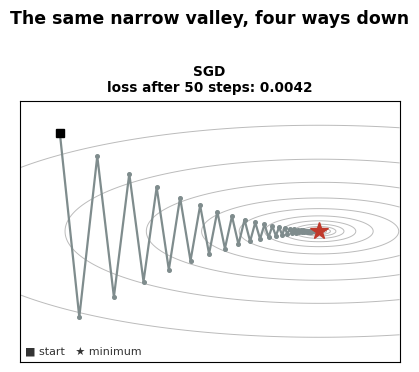

In [16]:
def valley_loss(w):
    """A long narrow valley: gentle along w[0], 25x steeper across w[1]."""
    return 0.5 * (w[0] ** 2 + 25 * w[1] ** 2)


def valley_grad(w):
    return np.array([w[0], 25 * w[1]])


class Point:
    """One point on the valley, dressed up as a layer so optimizers can move it."""
    def __init__(self, start):
        self.weights = np.array([start], dtype=float)
        self.biases = np.zeros((1, 1))


def walk(optimizer, steps=50, start=(-4.5, 1.2)):
    """Let an optimizer walk down the valley. Returns the path, shape (steps + 1, 2)."""
    p = Point(start)
    path = [p.weights[0].copy()]
    for _ in range(steps):
        p.dweights = valley_grad(p.weights[0])[None, :]
        p.dbiases = np.zeros((1, 1))
        optimizer.pre_update_params()
        optimizer.update_params(p)
        optimizer.post_update_params()
        path.append(p.weights[0].copy())
    return np.array(path)


fig = draw_valley_paths({"SGD": walk(Optimizer_SGD(0.075))}, valley_loss)
plt.show()

Your own SGD, zig-zagging. Every step overshoots across the steep direction, so it bounces
from wall to wall, while progress along the valley floor is slow. And you cannot fix it with the
learning rate: any larger and the bouncing grows until it flies off; any smaller and the crawl
along the floor gets even slower.

### The fix: remember which way you have been moving

**Momentum** gives the optimizer a memory of its recent steps. Each new step is part *the previous
step* and part *the current gradient*:

```
update  = momentum * previous_update  -  current_learning_rate * dweights
weights = weights + update
```

Think of a heavy ball rolling down the valley. The side-to-side pushes keep reversing, so they
**cancel out** in the memory. The push along the floor is always the same direction, so it
**builds up**. Zig-zag damped, progress accelerated. `momentum = 0.9` is the usual choice.


### Exercise 4 — SGD with momentum

The first time a layer is seen it has no previous update, so we start it at zeros (provided).


Exercise 4 passed


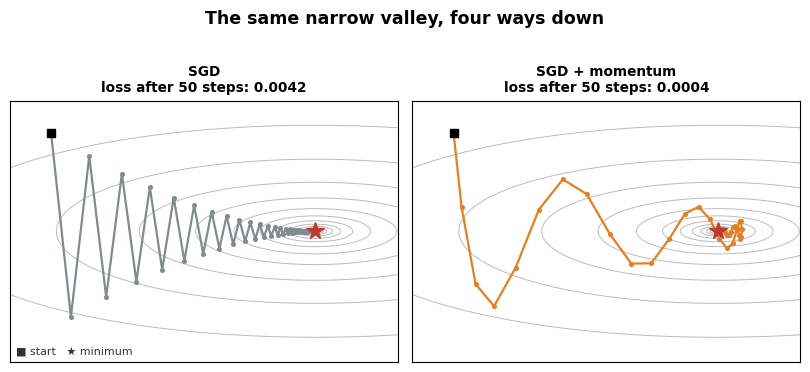

In [17]:
class Optimizer_SGD_Momentum(Optimizer):

    def __init__(self, learning_rate=1.0, decay=0.0, momentum=0.9):
        super().__init__(learning_rate, decay)
        self.momentum = momentum

    def update_params(self, layer):
        if not hasattr(layer, "weight_momentums"):          # first visit: no memory yet
            layer.weight_momentums = np.zeros_like(layer.weights)
            layer.bias_momentums = np.zeros_like(layer.biases)

        # TODO: new update = momentum * previous update  -  current lr * gradient
        layer.weight_momentums = self.momentum * layer.weight_momentums - self.current_learning_rate * layer.dweights
        layer.bias_momentums = self.momentum * layer.bias_momentums - self.current_learning_rate * layer.dbiases

        # TODO: apply the updates
        layer.weights += layer.weight_momentums
        layer.biases += layer.bias_momentums


# --- self-check ---
# constant gradient 1, lr 0.1, momentum 0.5:
#   step 1: -0.1     step 2: 0.5*(-0.1) - 0.1 = -0.15     step 3: 0.5*(-0.15) - 0.1 = -0.175
w = take_steps(Optimizer_SGD_Momentum(0.1, momentum=0.5), FakeLayer([0.0], [1.0]), 3)
assert np.allclose(w, [-0.425]), f"0 - 0.1 - 0.15 - 0.175 = -0.425; got {w}"
w0 = take_steps(Optimizer_SGD_Momentum(0.1, momentum=0.0), FakeLayer([0.0], [1.0]), 3)
assert np.allclose(w0, [-0.3]), "with momentum 0 it must behave exactly like plain SGD"
print("Exercise 4 passed")

fig = draw_valley_paths({"SGD": walk(Optimizer_SGD(0.075)),
                         "SGD + momentum": walk(Optimizer_SGD_Momentum(0.03, momentum=0.8))},
                        valley_loss)
plt.show()

---
## Idea 6 — RMSProp: a step size for every parameter

Watch **RMSProp (C2W2L07)** — the next video in Andrew Ng's series after momentum (~7 min).

Momentum fixes the zig-zag by **remembering direction**. RMSProp attacks the same problem from a
different angle: **every parameter gets its own step size.**

It keeps a running average of each parameter's **squared** gradients — its `cache`, a measure of
how large that parameter's gradients usually are — and divides each step by the square root:

```
cache   = rho * cache  +  (1 - rho) * dweights ** 2
weights = weights - current_learning_rate * dweights / (sqrt(cache) + epsilon)
```

* A parameter with **large** gradients (the steep direction) is divided by a large number →
  **smaller steps**. The bouncing stops.
* A parameter with **small** gradients (the gentle direction) is divided by a small number →
  **bigger steps**. The crawl speeds up.

`rho` (often 0.9) controls how long the memory lasts. `epsilon` is a tiny number that only exists to
avoid dividing by zero.


### Exercise 5 — RMSProp

In [19]:
class Optimizer_RMSprop(Optimizer):

    def __init__(self, learning_rate=0.001, decay=0.0, epsilon=1e-7, rho=0.9):
        super().__init__(learning_rate, decay)
        self.epsilon = epsilon
        self.rho = rho

    def update_params(self, layer):
        if not hasattr(layer, "weight_cache"):
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_cache = np.zeros_like(layer.biases)
        layer.weight_cache = self.rho * layer.weight_cache + (1 - self.rho) * (layer.dweights ** 2)
        layer.bias_cache = self.rho * layer.bias_cache + (1 - self.rho) * (layer.dbiases ** 2)
        layer.weights += -self.current_learning_rate * layer.dweights / (np.sqrt(layer.weight_cache) + self.epsilon)
        layer.biases += -self.current_learning_rate * layer.dbiases / (np.sqrt(layer.bias_cache) + self.epsilon)


w_small = take_steps(Optimizer_RMSprop(0.1, rho=0.9), FakeLayer([0.0], [2.0]), 1)
assert np.allclose(w_small, [-0.31622777], atol=1e-6), f"expected -0.3162, got {w_small}"
w_big = take_steps(Optimizer_RMSprop(0.1, rho=0.9), FakeLayer([0.0], [200.0]), 1)
assert np.allclose(w_big, w_small, atol=1e-6), \
    "RMSProp should take the same step whether the gradient is 2 or 200"
print("Exercise 5 passed")
print(f"\nfirst step with gradient 2   : {w_small[0]:+.4f}")
print(f"first step with gradient 200 : {w_big[0]:+.4f}   <- same size. That is the point.")

Exercise 5 passed

first step with gradient 2   : -0.3162
first step with gradient 200 : -0.3162   <- same size. That is the point.


---
## Idea 7 — Adam: momentum and RMSProp together

Watch **[Adam Optimization Algorithm](https://www.youtube.com/watch?v=JXQT_vxqwIs)** (Andrew Ng,
~7 min).

Momentum remembers **direction**. RMSProp remembers **size**. They fix different weaknesses, so the
obvious move is to use both. That is **Adam** (*adaptive moment estimation*, 2014), and it is the
usual first choice today.


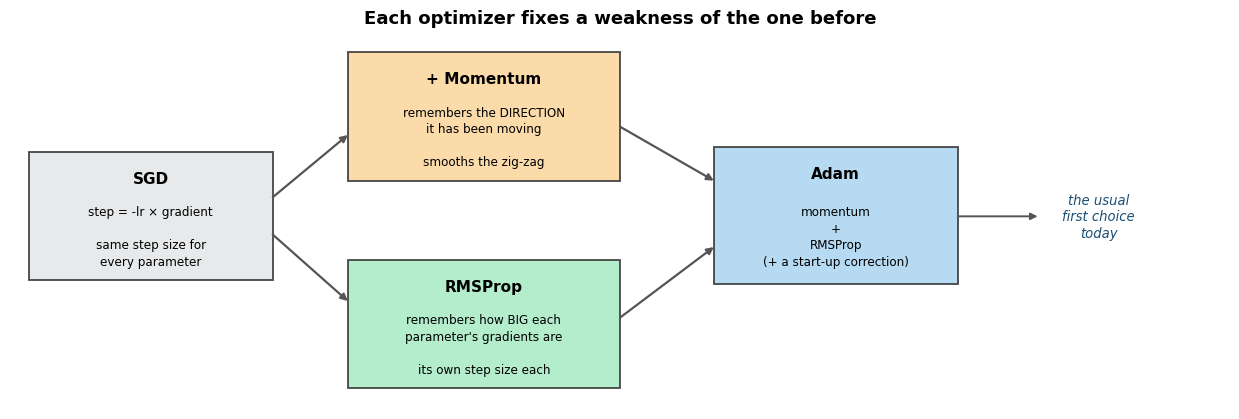

In [20]:
fig = draw_optimizer_family()
plt.show()

Adam keeps two running averages for every parameter:

```
momentum = beta_1 * momentum + (1 - beta_1) * dweights          <- direction  (like momentum)
cache    = beta_2 * cache    + (1 - beta_2) * dweights ** 2     <- size       (like RMSProp)
```

with the usual values `beta_1 = 0.9` and `beta_2 = 0.999`.

### The start-up correction

Both averages start at **zero**, so for the first few steps they are much too small — biased
towards zero. Adam fixes this by dividing by a correction that is large early and fades to 1:

```
momentum_corrected = momentum / (1 - beta_1 ** (iterations + 1))
cache_corrected    = cache    / (1 - beta_2 ** (iterations + 1))
```

The `+ 1` matters: `iterations` starts at 0, and `1 - beta ** 0` is zero — a division by zero.

Then the step looks just like RMSProp, but using the corrected momentum instead of the raw
gradient:

```
weights = weights - current_learning_rate * momentum_corrected / (sqrt(cache_corrected) + epsilon)
```


### Exercise 6 — Adam

In [21]:
class Optimizer_Adam(Optimizer):

    def __init__(self, learning_rate=0.001, decay=0.0, epsilon=1e-7, beta_1=0.9, beta_2=0.999):
        super().__init__(learning_rate, decay)
        self.epsilon = epsilon
        self.beta_1 = beta_1
        self.beta_2 = beta_2

    def update_params(self, layer):
        if not hasattr(layer, "weight_cache"):
            layer.weight_momentums = np.zeros_like(layer.weights)
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_momentums = np.zeros_like(layer.biases)
            layer.bias_cache = np.zeros_like(layer.biases)

        t = self.iterations + 1                               

        layer.weight_momentums = self.beta_1 * layer.weight_momentums + (1 - self.beta_1) * layer.dweights
        layer.bias_momentums = self.beta_1 * layer.bias_momentums + (1 - self.beta_1) * layer.dbiases
        layer.weight_cache = self.beta_2 * layer.weight_cache + (1 - self.beta_2) * (layer.dweights ** 2)
        layer.bias_cache = self.beta_2 * layer.bias_cache + (1 - self.beta_2) * (layer.dbiases ** 2)
        w_mom = layer.weight_momentums / (1 - self.beta_1 ** t)
        b_mom = layer.bias_momentums / (1 - self.beta_1 ** t)
        w_cache = layer.weight_cache / (1 - self.beta_2 ** t)
        b_cache = layer.bias_cache / (1 - self.beta_2 ** t)
        layer.weights += -self.current_learning_rate * w_mom / (np.sqrt(w_cache) + self.epsilon)
        layer.biases += -self.current_learning_rate * b_mom / (np.sqrt(b_cache) + self.epsilon)

# --- self-check ---
# Thanks to the correction, Adam's FIRST step is exactly the learning rate in size,
# whatever the gradient.
w_a = take_steps(Optimizer_Adam(0.1), FakeLayer([0.0], [2.0]), 1)
w_b = take_steps(Optimizer_Adam(0.1), FakeLayer([0.0], [200.0]), 1)
assert not np.any(np.isnan(w_a)), "nan - did you use iterations + 1 in the correction?"
assert np.allclose(w_a, [-0.1], atol=1e-5), f"first step should be -0.1, got {w_a}"
assert np.allclose(w_b, [-0.1], atol=1e-5), "and it should not depend on the gradient's size"

w5 = take_steps(Optimizer_Adam(0.1), FakeLayer([0.0], [1.0]), 5)
assert np.allclose(w5, [-0.5], atol=1e-4), "a steady gradient should give steady steps of 0.1"
print("Exercise 6 passed")

Exercise 6 passed


All four optimizers, down the same valley. Every one of these paths is **your code**.

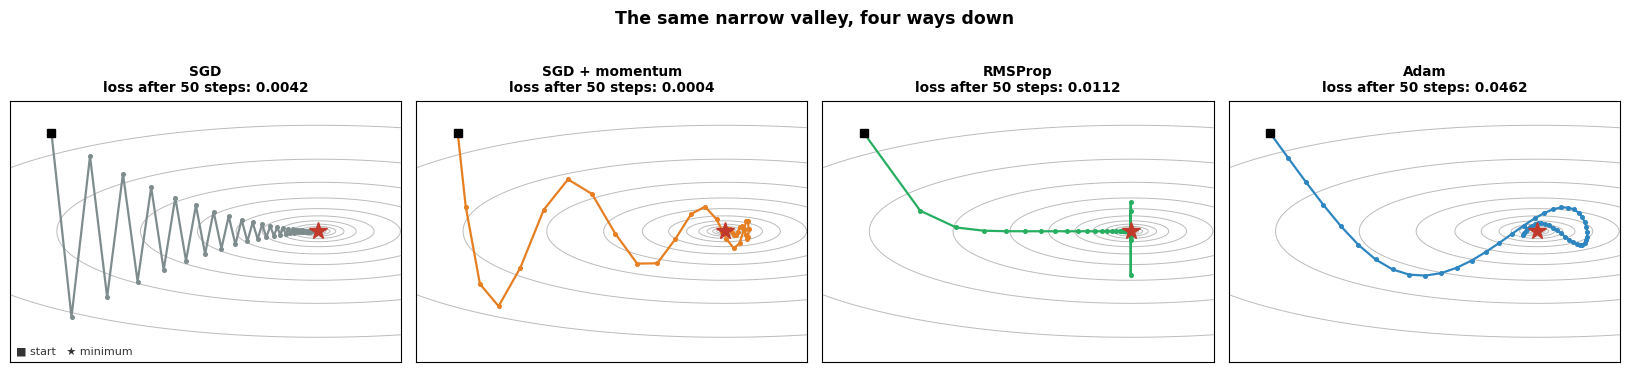

In [22]:
paths = {
    "SGD":            walk(Optimizer_SGD(0.075)),
    "SGD + momentum": walk(Optimizer_SGD_Momentum(0.03, momentum=0.8)),
    "RMSProp":        walk(Optimizer_RMSprop(0.3, rho=0.9)),
    "Adam":           walk(Optimizer_Adam(0.3)),
}
fig = draw_valley_paths(paths, valley_loss)
plt.show()

Four different personalities:

* **SGD** bounces wall to wall.
* **Momentum** swings wide at first, then its memory settles it into the valley.
* **RMSProp** heads almost straight for the valley floor — the steep direction's steps were
  shrunk — then travels along it.
* **Adam** curves in smoothly, then circles the minimum as its momentum carries it past.

Look at the loss in each title. On this particular surface **momentum finishes lowest** — Adam is
not the best at everything. Hold that thought for the Assessment.


### Checkpoint 2

1. Momentum and RMSProp both reduce zig-zagging. In one sentence each, how does each one do it?
2. Why does Adam need a start-up correction at all?
3. What would happen in Adam's correction if you used `iterations` instead of `iterations + 1`?


> **Your answers:**
>
> 1. *(Momentum: Cancels out opposing oscillations by accumulating momentum from past gradients.
RMSProp: Normalizes step sizes by dividing by recent gradient magnitudes to smooth steep updates.)*
> 2. *(Zero-bias: Momentums start at 0, making early gradient estimates artificially small.)*
> 3. *(Division by zero = NAN)*


# Stage 4 · Race them

# Assessment

**Marks: 1**

Same network, same spiral, same starting weights, same number of epochs. Only the optimizer
changes. The hyperparameters are the ones NNFS Chapter 10 settles on, so you can compare your
results with the book.

The training set is used for learning; the **test set** is new spiral data the network never sees
during training.


### Q1 — The race

Train each configuration for **10,000 epochs**, full batch. This takes about 15 seconds.


In [ ]:
race = {
    "SGD":            lambda: Optimizer_SGD(1.0),
    "SGD + decay":    lambda: Optimizer_SGD(1.0, decay=1e-3),
    "SGD + momentum": lambda: Optimizer_SGD_Momentum(1.0, decay=1e-3, momentum=0.9),
    "RMSProp":        lambda: Optimizer_RMSprop(0.02, decay=1e-5, rho=0.999),
    "Adam":           lambda: Optimizer_Adam(0.05, decay=5e-7),
}

results, histories, nets = {}, {}, {}
t_start = time.time()
for name, make_optimizer in race.items():
    net, hist = train(make_optimizer(), X_train, y_train, 10000)
    nets[name], histories[name] = net, hist
    results[name] = (hist[-1][2], hist[-1][1], net.accuracy(X_test, y_test))

print(f"{'optimizer':<16} {'train acc':>10} {'train loss':>11} {'test acc':>9}")
print("-" * 50)
for name, (tr_acc, tr_loss, te_acc) in results.items():
    print(f"{name:<16} {tr_acc:>10.3f} {tr_loss:>11.3f} {te_acc:>9.3f}")
print(f"\n({time.time() - t_start:.0f} seconds)")

# --- self-check ---
assert len(results) == 5 and all(len(v) == 3 for v in results.values())
assert results["Adam"][0] > 0.9, "Adam should fit the training data well"
assert results["SGD"][0] < 0.8, "plain SGD should still be struggling"
assert results["SGD + momentum"][0] > results["SGD"][0] + 0.15, "momentum should help a lot"
print("Q1 passed")

Now look at the race, and at what the fastest and slowest networks actually learned.

In [ ]:
fig = draw_loss_curves(histories, title="The optimizer race: 10,000 epochs on the spiral")
plt.show()

predict = lambda net: (lambda P: (net.forward(P, np.zeros(len(P), dtype=int)),
                                  np.argmax(net.loss_activation.output, axis=1))[1])
fig = draw_decision_boundaries({"SGD": predict(nets["SGD"]),
                                "SGD + momentum": predict(nets["SGD + momentum"]),
                                "Adam": predict(nets["Adam"])},
                               X_train, y_train)
plt.show()

Look closely at the boundaries. Plain SGD has barely begun to bend. Momentum and Adam trace
the spirals — but they also carve **small islands and spikes around individual points**, especially
near the centre. Real spirals do not look like that. Keep this picture in mind for Q3(2).


### Q2 — Is Adam tuning-free?

"Adaptive" optimizers adjust their step sizes — so do they still need a good learning rate? Train
Adam at five learning rates, **2,000 epochs** each, full batch.


In [ ]:
lr_results = []
for lr in [0.0005, 0.005, 0.05, 0.5, 2.0]:
    # TODO: train with Adam at this learning rate (no decay), 2000 epochs
    net, hist = ...
    # TODO: record (lr, final training accuracy, highest loss seen during training)
    lr_results.append((lr, ..., ...))

print(f"{'learning rate':>13} {'train acc':>10} {'worst loss seen':>16}")
print("-" * 42)
for lr, acc, worst in lr_results:
    print(f"{lr:>13} {acc:>10.3f} {worst:>16.2f}")

# --- self-check ---
accs = {lr: a for lr, a, _ in lr_results}
assert accs[0.05] > accs[0.0005], "a sensible learning rate should beat a tiny one"
assert accs[0.05] > accs[2.0] + 0.3, "and a huge one should fail badly"
print("\nQ2 passed")

---

## What you built today

Real backpropagation, checked against Lab 2 and about 270× faster, and four optimizers written
from scratch:

| Optimizer | You wrote | Remembers | Fixes |
|---|---|---|---|
| SGD | `Optimizer_SGD` | nothing | — the baseline |
| + mini-batches | `get_batches` | — | too few updates per epoch |
| + momentum | `Optimizer_SGD_Momentum` | **direction** | zig-zagging |
| RMSProp | `Optimizer_RMSprop` | **size**, per parameter | one step size for everything |
| Adam | `Optimizer_Adam` | **both** | combines the two |

And one uncomfortable number: the best optimizer reached about **0.96 on the training data but
only about 0.82 on new data.**


### Before next week

* Restart the kernel and run everything top to bottom. Every assertion should pass.
* Keep this notebook. `SpiralNet`, `train` and all four optimizers come back in Lab 6.
* Read NNFS Chapter 10 alongside your code — your classes should look very like the book's.

---

### Submission

1. Create a new repository on GitHub for this course and name it `arti402`.
2. Rename this file to `arti402_Lab5_<YourID>.ipynb` and upload the completed notebook, with all
   outputs visible, to your repository.
